In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
# set the max length for the model
pretrained_model_name = 'hyenadna-tiny-1k-seqlen'

max_lengths = {
        'hyenadna-tiny-1k-seqlen': 1024,
        'hyenadna-small-32k-seqlen': 32768,
        'hyenadna-medium-160k-seqlen': 160000,
        'hyenadna-medium-450k-seqlen': 450000,  # T4 up to here
        'hyenadna-large-1m-seqlen': 1_000_000,  # only A100 (paid tier)
    }

max_length = max_lengths[pretrained_model_name]  # auto selects

In [3]:
from standalone_hyenadna import CharacterTokenizer

# create tokenizer
tokenizer = CharacterTokenizer(
    characters=['A', 'C', 'G', 'T', 'N'],  # add DNA characters, N is uncertain
    model_max_length=max_length + 2,  # to account for special tokens, like EOS
    add_special_tokens=False,  # we handle special tokens elsewhere
    padding_side='left', # since HyenaDNA is causal, we pad on the left
)

In [4]:
import torch

n_classes = 2
use_head =  True
device = 'cuda' if torch.cuda.is_available() else 'cpu' # use cuda for models 1k up to 160k sequence length
# device = 'cpu'  # use cpu for models 450k up to 1m sequence length
print("Using device:", device)

Using device: cuda


In [10]:
from huggingface import HyenaDNAPreTrainedModel

# when loading a model, the corresponding checkpoint is downloaded from the huggingface model hub
model = HyenaDNAPreTrainedModel.from_pretrained(
            './checkpoints',
            pretrained_model_name,
            download = True,
            config = None,
            device = device,
            use_head =  use_head,
            n_classes = n_classes,
        )

Updated Git hooks.
Git LFS initialized.


Cloning into 'hyenadna-tiny-1k-seqlen'...


Loaded pretrained weights ok!


In [11]:
# create a sample 450k long, prepare
sequence = 'ACGT' * int(max_length/4)
tok_seq = tokenizer(sequence)
tok_seq = tok_seq["input_ids"]  # grab ids

# place on device, convert to tensor
tok_seq = torch.LongTensor(tok_seq).unsqueeze(0)  # unsqueeze for batch dim
tok_seq = tok_seq.to(device)

In [13]:
# prep model and forward
model.to(device)
model.eval()
with torch.inference_mode():
    output = model(tok_seq)

print("Output shape:", output)

Output shape: tensor([[-0.0904, -0.0208]], device='cuda:0')


In [17]:
# experiment settings:
num_epochs = 100  # ~100 seems fine
max_length = 500  # max len of sequence of dataset (of what you want)
use_padding = True
dataset_path = 'content/genomic_benchmarks'
dataset_name = 'human_enhancers_cohn'
batch_size = 256
learning_rate = 6e-4  # good default for Hyena
rc_aug = True  # reverse complement augmentation
add_eos = False  # add end of sentence token
weight_decay = 0.1

In [18]:
from src.dataloaders.datasets.genomic_bench_dataset import GenomicBenchmarkDataset

# create a dataset
ds_train = GenomicBenchmarkDataset(
        max_length = max_length,
        use_padding = use_padding,
        split = 'train',
        tokenizer=tokenizer,
        dest_path=dataset_path,
        dataset_name=dataset_name,
        rc_aug=rc_aug,
        add_eos=add_eos,
    )

ds_test = GenomicBenchmarkDataset(
        max_length = max_length,
        use_padding = use_padding,
        split = 'test',
        tokenizer=tokenizer,
        dest_path=dataset_path,
        dataset_name=dataset_name,
        rc_aug=rc_aug,
        add_eos=add_eos,
    )

already downloaded train-human_enhancers_cohn
already downloaded test-human_enhancers_cohn


In [51]:
from torch.utils.data import DataLoader

batch_size = 64
train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(ds_test, batch_size=batch_size, shuffle=True)

In [21]:
from torch import nn, optim
learning_rate = 1e-3
weight_decay = 0.1

# loss function
loss_fn = nn.CrossEntropyLoss()

# create optimizer
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

model.to(device)


HyenaDNAModel(
  (backbone): LMBackbone(
    (embeddings): GPT2Embeddings(
      (word_embeddings): Embedding(16, 128)
    )
    (layers): ModuleList(
      (0): Block(
        (mixer): HyenaOperator(
          (dropout): Dropout(p=0.0, inplace=False)
          (in_proj): Linear(in_features=128, out_features=384, bias=True)
          (out_proj): Linear(in_features=128, out_features=128, bias=True)
          (short_filter): Conv1d(384, 384, kernel_size=(3,), stride=(1,), padding=(2,), groups=384)
          (filter_fn): HyenaFilter(
            (dropout): Dropout(p=0.0, inplace=False)
            (pos_emb): PositionalEmbedding()
            (implicit_filter): Sequential(
              (0): Linear(in_features=5, out_features=64, bias=True)
              (1): Sin()
              (2): Linear(in_features=64, out_features=64, bias=True)
              (3): Sin()
              (4): Linear(in_features=64, out_features=64, bias=True)
              (5): Sin()
              (6): Linear(in_features=

In [55]:
def train(model, device, train_loader, optimizer, epoch, loss_fn, log_interval=10):
    """Training loop."""
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = loss_fn(output, target.squeeze())
        loss.backward()
        optimizer.step()
        if batch_idx % log_interval == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))

def test(model, device, test_loader, loss_fn):
    """Test loop."""
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += loss_fn(output, target.squeeze()).item()  # sum up batch loss
            pred = output.argmax(dim=1, keepdim=True)  # get the index of the max log-probability
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)

    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.2f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))
    
def run_train(model, train_loader, test_loader, loss_fn, optimizer, num_epochs=5, device='cpu'):
        for epoch in range(num_epochs):
                train(model, device, train_loader, optimizer, epoch, loss_fn)
                test(model, device, test_loader, loss_fn)
                optimizer.step()

In [56]:
run_train(model, train_loader, test_loader, loss_fn, optimizer, num_epochs=100, device=device)

Train Epoch: 0 [0/20843 (0%)]	Loss: 0.549268
Train Epoch: 0 [640/20843 (3%)]	Loss: 0.573380
Train Epoch: 0 [1280/20843 (6%)]	Loss: 0.466786
Train Epoch: 0 [1920/20843 (9%)]	Loss: 0.451024
Train Epoch: 0 [2560/20843 (12%)]	Loss: 0.601699
Train Epoch: 0 [3200/20843 (15%)]	Loss: 0.505773
Train Epoch: 0 [3840/20843 (18%)]	Loss: 0.607225
Train Epoch: 0 [4480/20843 (21%)]	Loss: 0.467307
Train Epoch: 0 [5120/20843 (25%)]	Loss: 0.575307
Train Epoch: 0 [5760/20843 (28%)]	Loss: 0.564657
Train Epoch: 0 [6400/20843 (31%)]	Loss: 0.519042
Train Epoch: 0 [7040/20843 (34%)]	Loss: 0.563749
Train Epoch: 0 [7680/20843 (37%)]	Loss: 0.489874
Train Epoch: 0 [8320/20843 (40%)]	Loss: 0.520114
Train Epoch: 0 [8960/20843 (43%)]	Loss: 0.561889
Train Epoch: 0 [9600/20843 (46%)]	Loss: 0.516235
Train Epoch: 0 [10240/20843 (49%)]	Loss: 0.506566
Train Epoch: 0 [10880/20843 (52%)]	Loss: 0.491214
Train Epoch: 0 [11520/20843 (55%)]	Loss: 0.550180
Train Epoch: 0 [12160/20843 (58%)]	Loss: 0.601562
Train Epoch: 0 [12800/20

In [52]:
# Get a batch of test data
data, target = next(iter(test_loader))
data, target = data.to(device), target.to(device)

# Set the model to evaluation mode and disable gradient computation
model.eval()
with torch.no_grad():
    output = model(data)

# Calculate the loss
loss = loss_fn(output, target.squeeze())

# Get the predicted class
pred = output.argmax(dim=1, keepdim=True)

# Calculate accuracy
correct = pred.eq(target.view_as(pred)).sum().item()
accuracy = 100. * correct / len(target)

print(f'Loss: {loss.item():.4f}, Accuracy: {accuracy:.2f}%')

Loss: 0.6174, Accuracy: 60.94%


In [53]:
print(pred.squeeze())
print(target.squeeze())

tensor([1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0,
        1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1,
        1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0], device='cuda:0')
tensor([1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0,
        1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1,
        1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0], device='cuda:0')


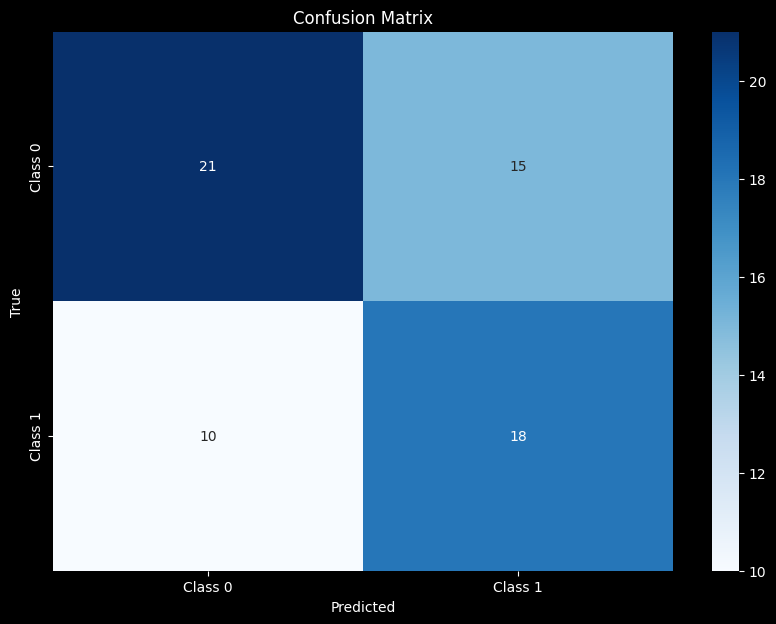

In [54]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt

# Convert tensors to numpy arrays
pred_np = pred.cpu().numpy()
target_np = target.cpu().numpy()

# Compute confusion matrix
cm = confusion_matrix(target_np, pred_np)

# Plot confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [29]:
cm

array([[39, 25],
       [ 0,  0]])